<a href="https://colab.research.google.com/github/Gaurav94-mad/AI-Powered-Customer-Churn-Prediction-Model/blob/main/Household_Financial_%26_Socio_Economic_Segmentation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HOUSEHOLD FINANCIAL & SOCIO-ECONOMIC SEGMENTATION

Identify measurable household financial and socio-economic segments
to support targeted financial products, responsible credit,
insurance penetration, digital-finance adoption and financial
inclusion strategies.

Business KPIs:
- Income
- Expenditure
- Savings
- Debt burden
- Savings rate
- Insurance coverage
- Bank-account ownership
- Smartphone/internet adoption
- Consumer durables


Dataset shape: (2015, 29)

Columns:
['household_id', 'state', 'region_type', 'district_literacy_rate_pct', 'district_urbanisation_rate_pct', 'district_population_density', 'district_female_workforce_participation_pct', 'household_size', 'num_earning_members', 'age_of_head', 'education_head', 'occupation_head', 'monthly_household_income_inr', 'monthly_household_expenditure_inr', 'food_expenditure_share_pct', 'non_food_expenditure_share_pct', 'monthly_savings_inr', 'outstanding_debt_inr', 'housing_type', 'house_structure', 'vehicle_owned', 'smartphone_owne

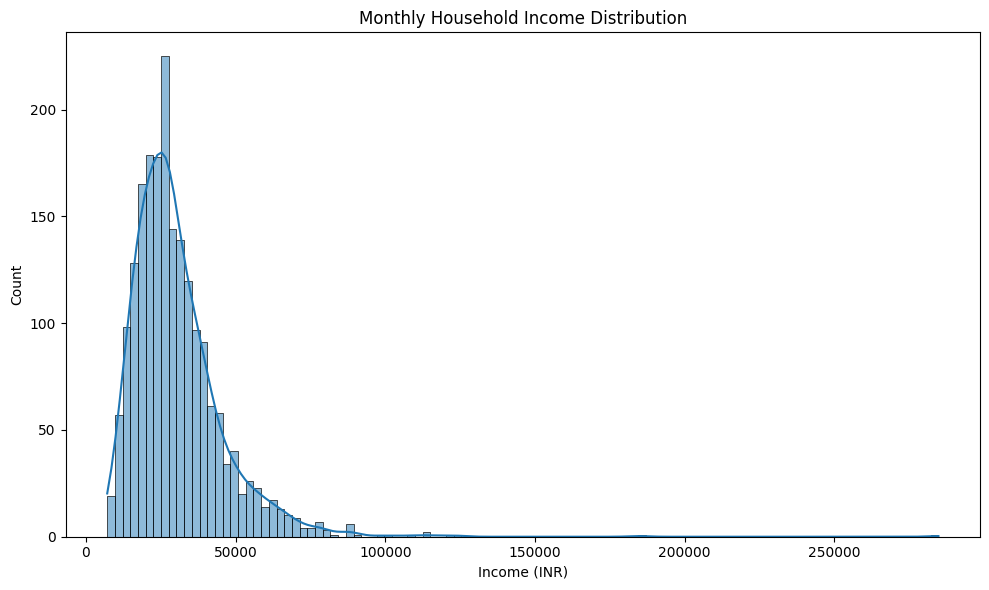

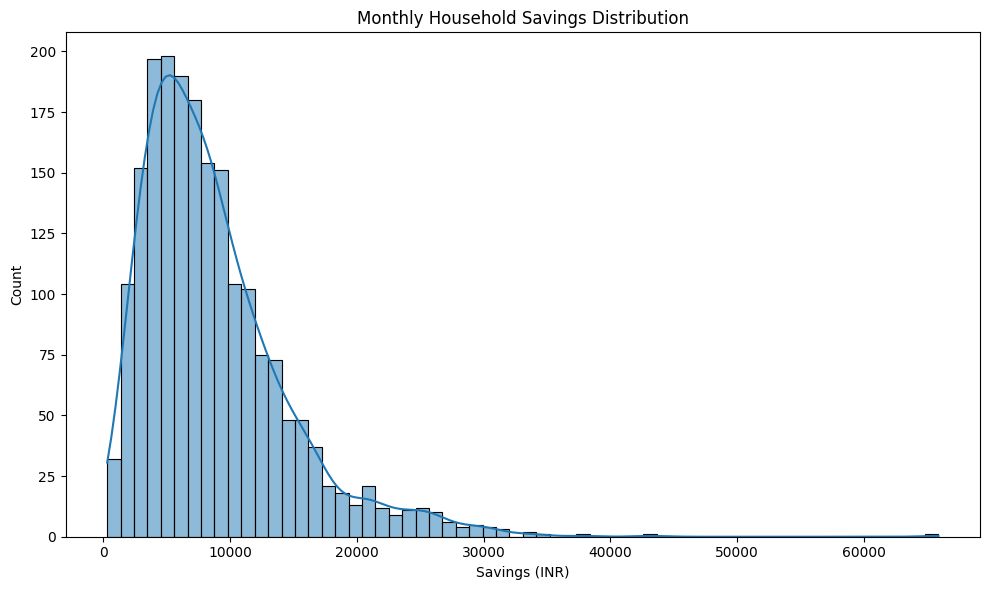

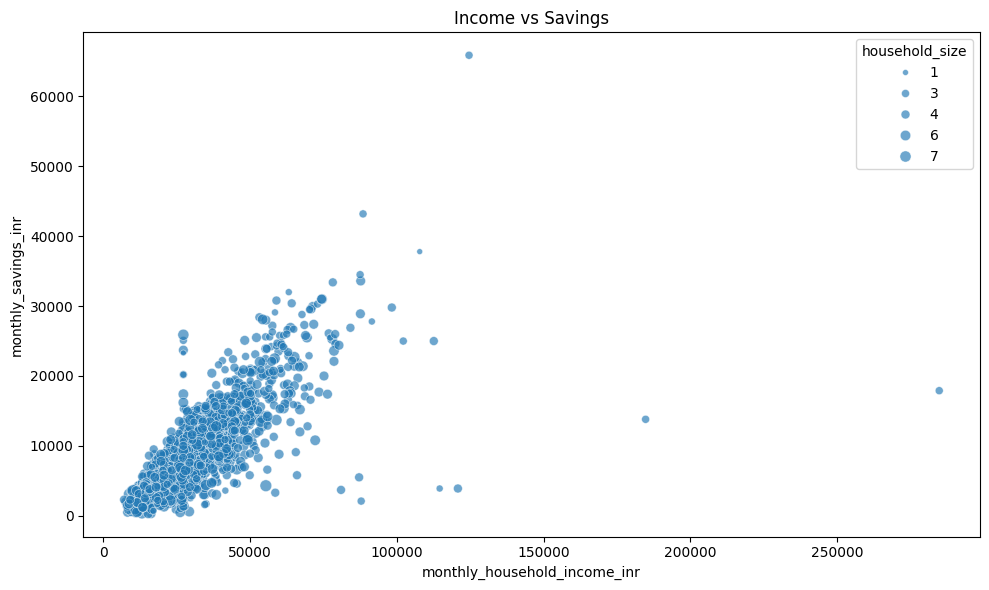

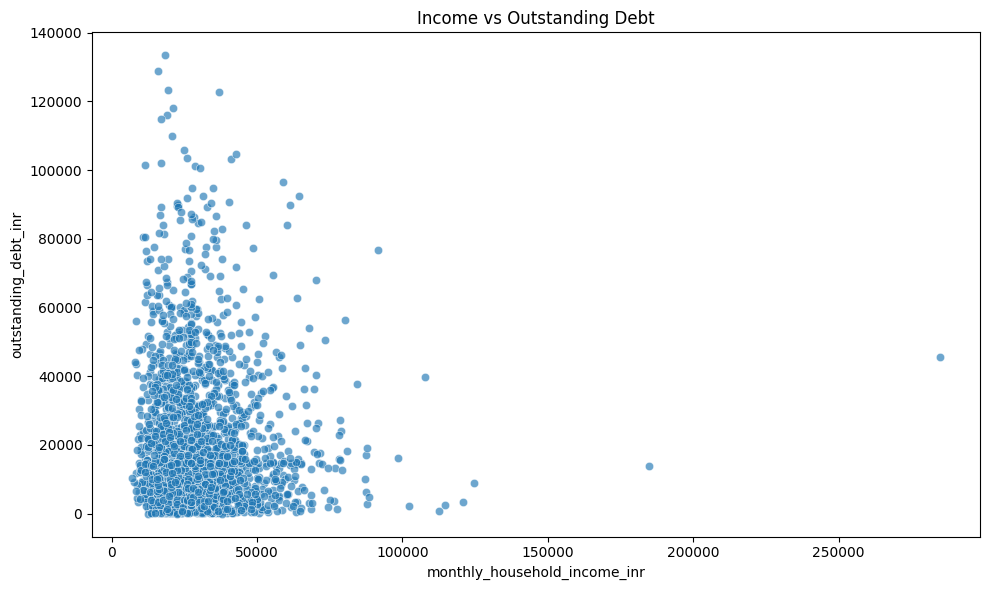

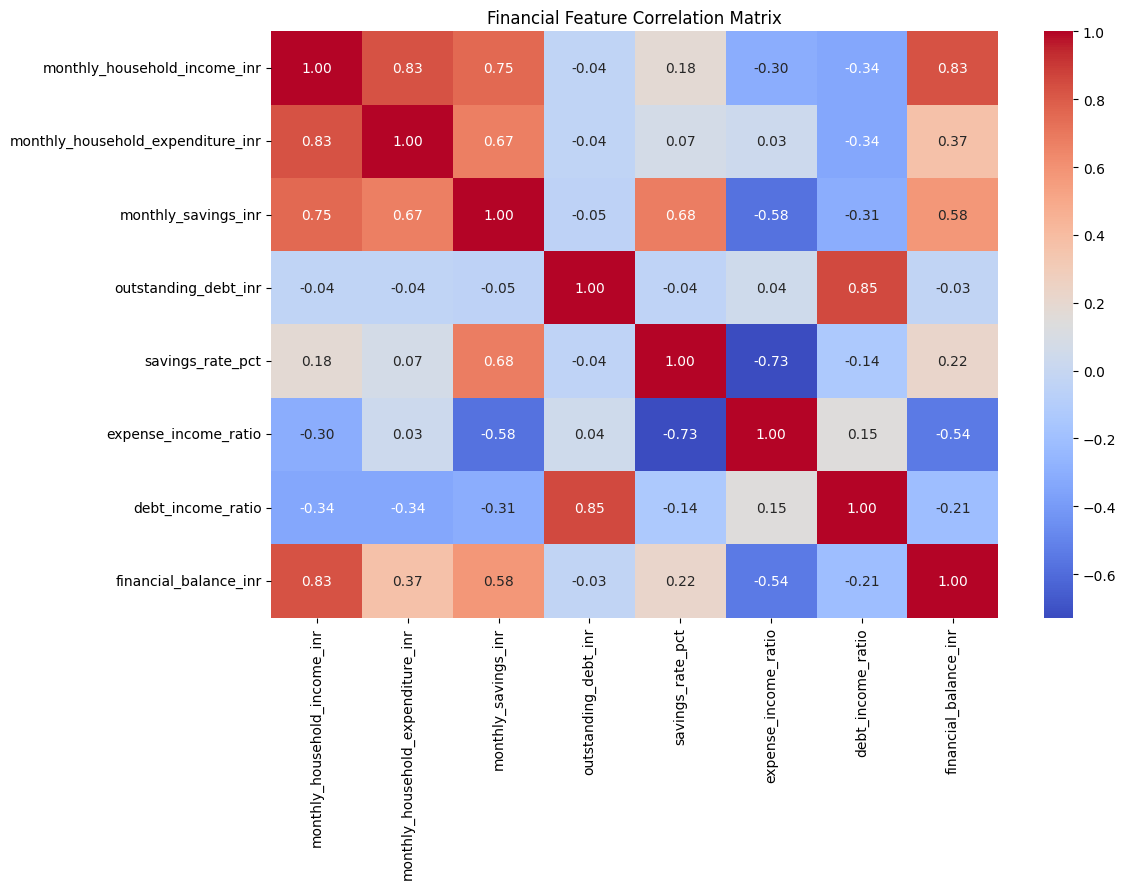

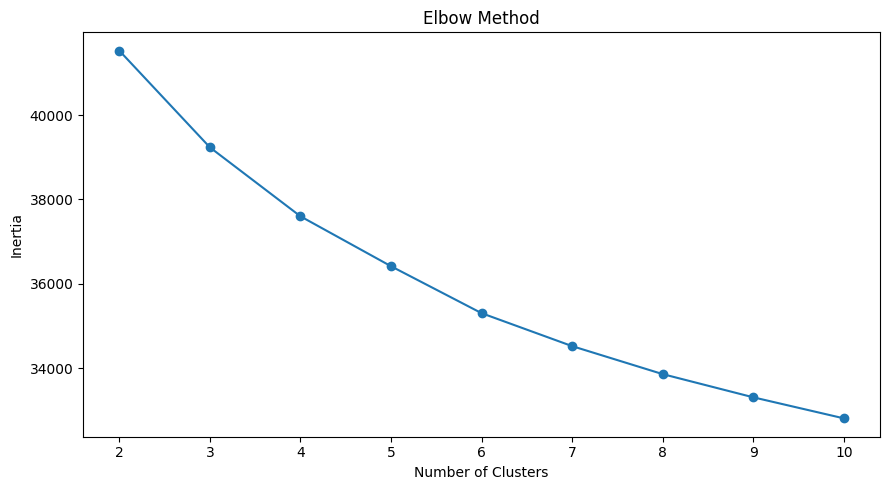

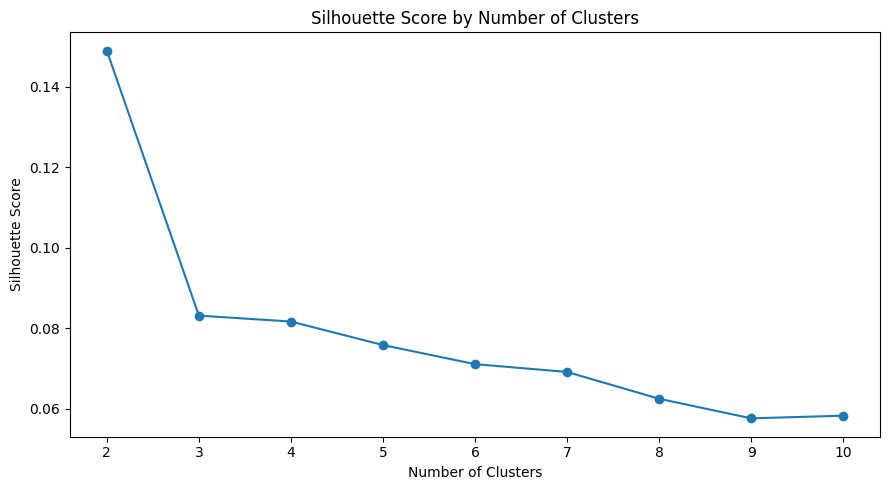

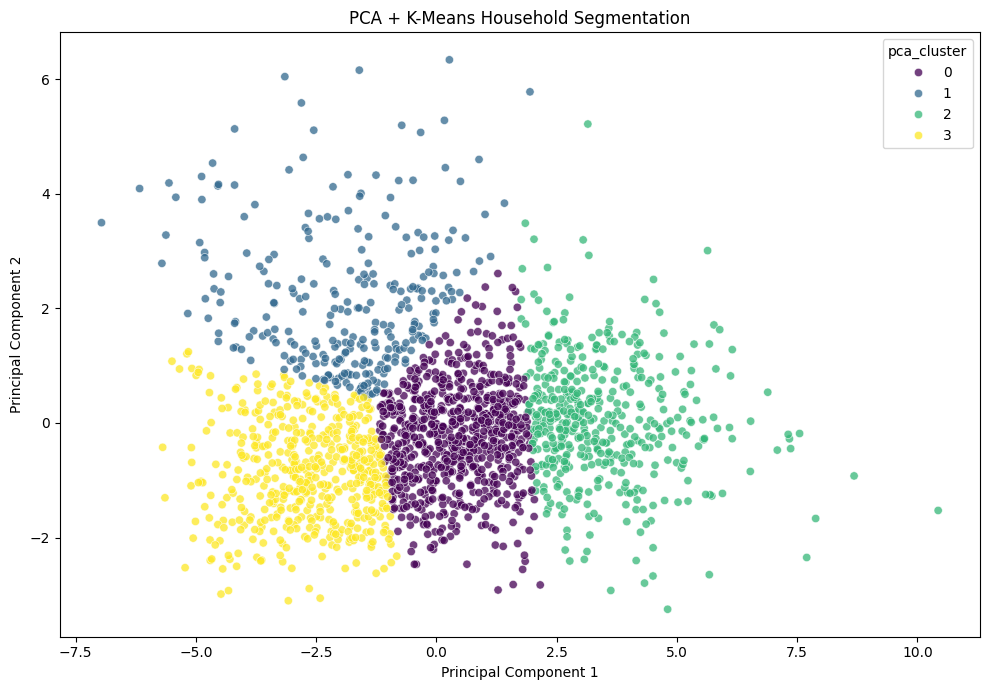


CLUSTERING COMPARISON
           Model  Silhouette Score  Davies-Bouldin Index  \
0        K-Means          0.081691              2.641909   
1   Hierarchical          0.058265              3.078856   
2  PCA + K-Means          0.371840              0.900421   

   Calinski-Harabasz Score  
0               219.447731  
1               175.816840  
2              1807.460393  

CLUSTER PROFILE
                monthly_household_income_inr  \
kmeans_cluster                                 
0                                   28606.61   
1                                   48620.64   
2                                   22344.98   
3                                   22271.35   

                monthly_household_expenditure_inr  monthly_savings_inr  \
kmeans_cluster                                                           
0                                        20476.58              8086.81   
1                                        31885.78             16216.93   
2                 

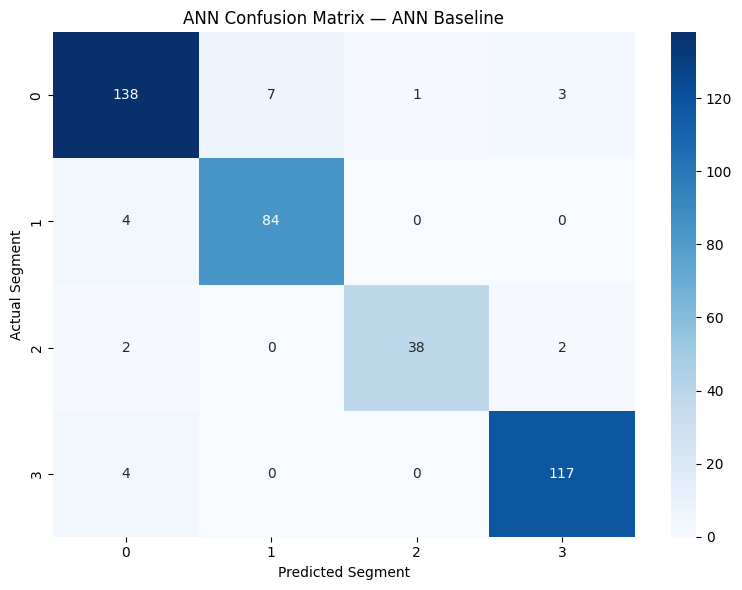

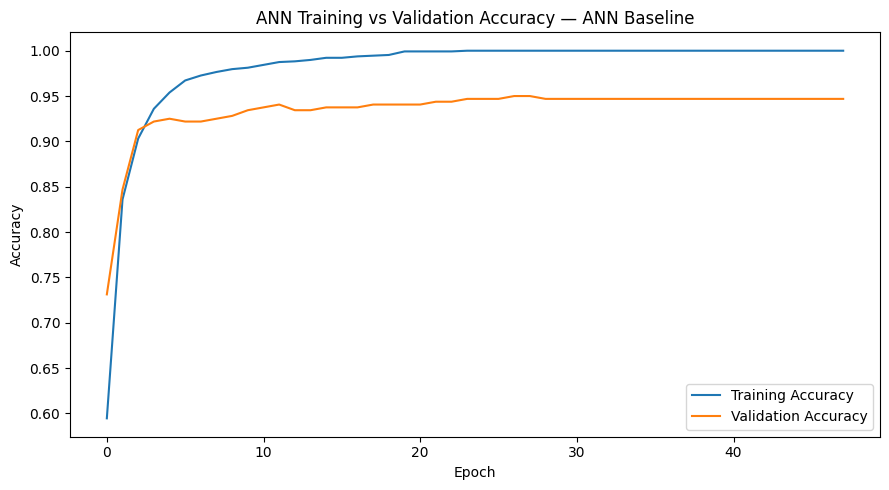

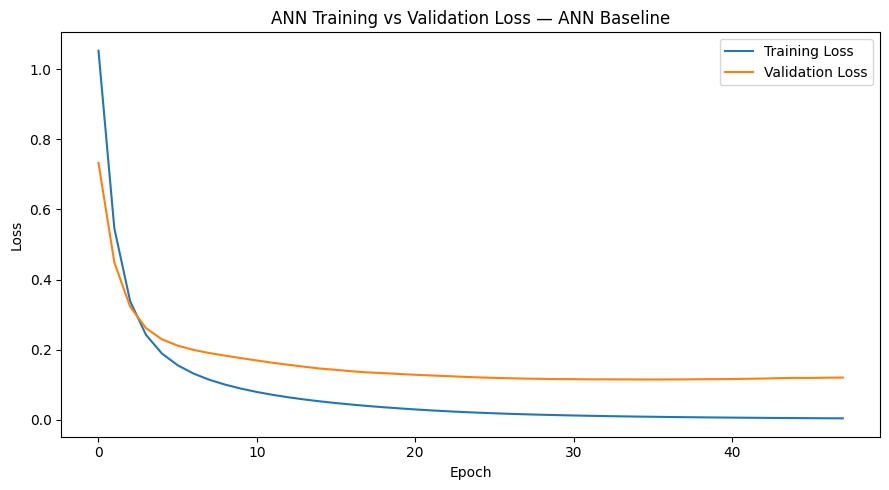

  0%|          | 0/150 [00:00<?, ?it/s]

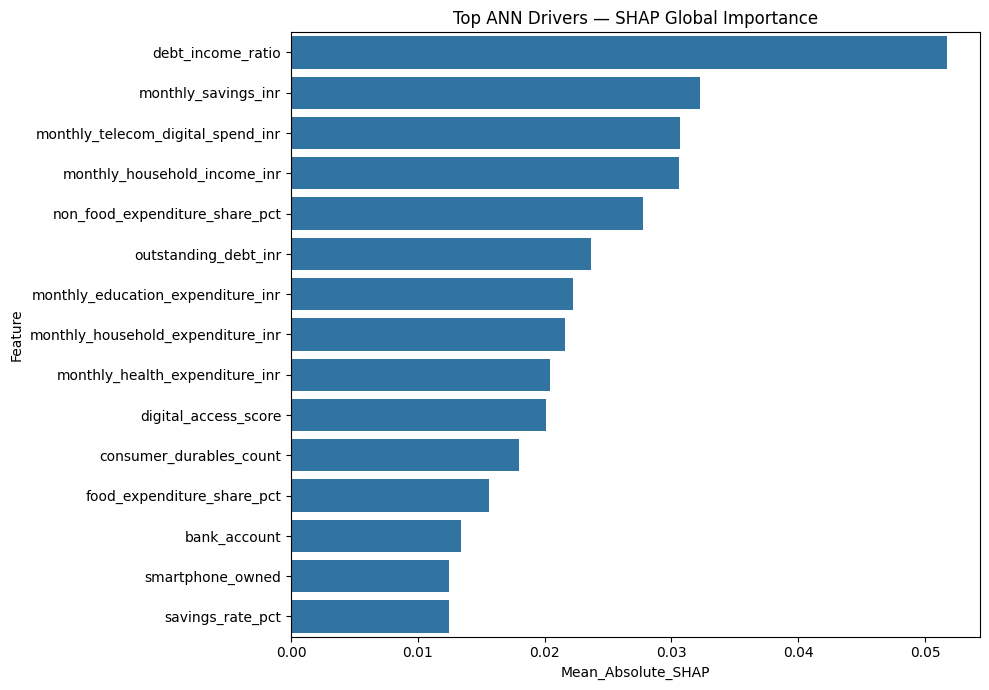


SHAP analysis completed.

MANAGERIAL INSIGHTS
 Cluster                       Business Segment  Households  Share %  Avg Income  Avg Savings  Avg Debt/Income  Avg Insurance Coverage  Avg Digital Access                                                                     Recommended Strategy
       0          Financially Stable / Affluent         743    37.15    28606.61      8086.81             0.56                    0.38                0.70           Target investments, wealth-management, insurance and premium banking products.
       1          Financially Stable / Affluent         443    22.15    48620.64     16216.93             0.42                    0.49                0.79           Target investments, wealth-management, insurance and premium banking products.
       2 Debt-Burdened / Financially Vulnerable         209    10.45    22344.98      5919.14             3.02                    0.27                0.51 Prioritize responsible lending, debt restructuring and financial-l

In [ ]:
# ================================================================
# HOUSEHOLD FINANCIAL & SOCIO-ECONOMIC SEGMENTATION SYSTEM
# Industry-style MBA / Data Science & AI Project
# ================================================================
# Pipeline:
# Business Problem → Cleaning → EDA → Descriptive Statistics
# → Visualization → K-Means → Hierarchical → PCA+Clustering
# → Cluster Profiling → ANN Classification → Hyperparameter Tuning
# → SHAP Explainability → Business Insights → Recommendations
#
# Dataset: Household records with financial, demographic,
# digital-access and socio-economic variables.
# ================================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Optional explainability
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False


# ================================================================
# 1. CONFIGURATION
# ================================================================

DATA_PATH = Path("/mnt/data/e59d4201-40f5-42c4-a5e1-9d9a9021a85b.csv")
OUTPUT_DIR = Path("household_segmentation_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
OPTIMAL_K = 4

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


# ================================================================
# 2. BUSINESS PROBLEM
# ================================================================

BUSINESS_PROBLEM = """
Identify measurable household financial and socio-economic segments
to support targeted financial products, responsible credit,
insurance penetration, digital-finance adoption and financial
inclusion strategies.

Business KPIs:
- Income
- Expenditure
- Savings
- Debt burden
- Savings rate
- Insurance coverage
- Bank-account ownership
- Smartphone/internet adoption
- Consumer durables
"""

print("=" * 75)
print("HOUSEHOLD FINANCIAL & SOCIO-ECONOMIC SEGMENTATION")
print("=" * 75)
print(BUSINESS_PROBLEM)


# ================================================================
# 3. LOAD DATA
# ================================================================

df = pd.read_csv("/content/consumer_segmentation_dataset.csv")

print("\nDataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

# Standardize categorical text
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# Normalize common inconsistent category values
if "region_type" in df.columns:
    df["region_type"] = df["region_type"].str.title()


# ================================================================
# 4. DATA QUALITY & CLEANING
# ================================================================

print("\nMissing values before cleaning:")
print(df.isna().sum().sort_values(ascending=False).head(15))

duplicate_count = df.duplicated().sum()
print("\nDuplicate rows:", duplicate_count)

df = df.drop_duplicates().copy()

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

# Median imputation for numeric data
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Mode imputation for categorical data
for col in categorical_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:", df.isna().sum().sum())


# ================================================================
# 5. FEATURE ENGINEERING
# ================================================================

income = "monthly_household_income_inr"
expense = "monthly_household_expenditure_inr"
savings = "monthly_savings_inr"
debt = "outstanding_debt_inr"

df["savings_rate_pct"] = np.where(
    df[income] > 0, df[savings] / df[income] * 100, 0
)

df["expense_income_ratio"] = np.where(
    df[income] > 0, df[expense] / df[income], 0
)

df["debt_income_ratio"] = np.where(
    df[income] > 0, df[debt] / df[income], 0
)

df["financial_balance_inr"] = df[income] - df[expense]

df["digital_access_score"] = (
    df["smartphone_owned"].astype(float)
    + df["internet_access"].astype(float)
    + df["bank_account"].astype(float)
) / 3

df["financial_stress_score"] = (
    df["debt_income_ratio"].clip(lower=0)
    + df["expense_income_ratio"].clip(lower=0)
)

# Winsorize extreme engineered ratios for more stable clustering
for col in ["debt_income_ratio", "expense_income_ratio"]:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lo, hi)


# ================================================================
# 6. DESCRIPTIVE STATISTICS
# ================================================================

financial_features = [
    income, expense, savings, debt,
    "savings_rate_pct", "expense_income_ratio",
    "debt_income_ratio", "financial_balance_inr"
]

financial_features = [c for c in financial_features if c in df.columns]

descriptive_stats = df[financial_features].describe().T
descriptive_stats["median"] = df[financial_features].median()
descriptive_stats["variance"] = df[financial_features].var()

print("\nDESCRIPTIVE STATISTICS")
print(descriptive_stats)

descriptive_stats.to_csv(
    OUTPUT_DIR / "descriptive_statistics.csv"
)


# ================================================================
# 7. EDA VISUALIZATION
# ================================================================

def save_show(fig, filename):
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


fig = plt.figure(figsize=(10, 6))
sns.histplot(df[income], kde=True)
plt.title("Monthly Household Income Distribution")
plt.xlabel("Income (INR)")
save_show(fig, "01_income_distribution.png")


fig = plt.figure(figsize=(10, 6))
sns.histplot(df[savings], kde=True)
plt.title("Monthly Household Savings Distribution")
plt.xlabel("Savings (INR)")
save_show(fig, "02_savings_distribution.png")


fig = plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x=income,
    y=savings,
    size="household_size",
    alpha=0.65
)
plt.title("Income vs Savings")
save_show(fig, "03_income_vs_savings.png")


fig = plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x=income,
    y=debt,
    alpha=0.65
)
plt.title("Income vs Outstanding Debt")
save_show(fig, "04_income_vs_debt.png")


corr_cols = [
    c for c in financial_features
    if c in df.select_dtypes(include=np.number).columns
]

fig = plt.figure(figsize=(12, 9))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Financial Feature Correlation Matrix")
save_show(fig, "05_correlation_heatmap.png")


# ================================================================
# 8. PREPARE CLUSTERING DATA
# ================================================================

# Numerical variables are preferred for financial segmentation.
# Binary indicators are retained as numeric features.

cluster_features = [
    "household_size",
    "num_earning_members",
    "age_of_head",
    "district_literacy_rate_pct",
    "district_urbanisation_rate_pct",
    "district_population_density",
    "district_female_workforce_participation_pct",
    income,
    expense,
    "food_expenditure_share_pct",
    "non_food_expenditure_share_pct",
    savings,
    debt,
    "smartphone_owned",
    "internet_access",
    "bank_account",
    "insurance_coverage",
    "consumer_durables_count",
    "monthly_telecom_digital_spend_inr",
    "monthly_health_expenditure_inr",
    "monthly_education_expenditure_inr",
    "savings_rate_pct",
    "debt_income_ratio",
    "expense_income_ratio",
    "digital_access_score"
]

cluster_features = [c for c in cluster_features if c in df.columns]

X_cluster = df[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


# ================================================================
# 9. SELECT NUMBER OF CLUSTERS
# ================================================================

k_values = range(2, 11)
inertias = []
silhouette_values = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

fig = plt.figure(figsize=(9, 5))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
save_show(fig, "06_elbow_method.png")

fig = plt.figure(figsize=(9, 5))
plt.plot(k_values, silhouette_values, marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
save_show(fig, "07_silhouette_scores.png")


# ================================================================
# 10. K-MEANS CLUSTERING
# ================================================================

kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=RANDOM_STATE,
    n_init=20
)

df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)


# ================================================================
# 11. HIERARCHICAL CLUSTERING
# ================================================================

hierarchical = AgglomerativeClustering(
    n_clusters=OPTIMAL_K,
    linkage="ward"
)

df["hierarchical_cluster"] = hierarchical.fit_predict(
    X_scaled
)


# ================================================================
# 12. PCA + K-MEANS
# ================================================================

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pd.DataFrame({
    "Component": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
    "Explained_Variance": pca_full.explained_variance_ratio_,
    "Cumulative_Variance": np.cumsum(
        pca_full.explained_variance_ratio_
    )
})

explained_variance.to_csv(
    OUTPUT_DIR / "pca_explained_variance.csv",
    index=False
)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=RANDOM_STATE,
    n_init=20
)

df["pca_cluster"] = pca_kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df["pca_cluster"],
    palette="viridis",
    alpha=0.75
)
plt.title("PCA + K-Means Household Segmentation")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
save_show(fig, "08_pca_clusters.png")


# ================================================================
# 13. CLUSTER MODEL COMPARISON
# ================================================================

def cluster_metrics(X, labels, model_name):
    return {
        "Model": model_name,
        "Silhouette Score": silhouette_score(X, labels),
        "Davies-Bouldin Index": davies_bouldin_score(X, labels),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            X, labels
        )
    }

cluster_results = pd.DataFrame([
    cluster_metrics(
        X_scaled,
        df["kmeans_cluster"],
        "K-Means"
    ),
    cluster_metrics(
        X_scaled,
        df["hierarchical_cluster"],
        "Hierarchical"
    ),
    cluster_metrics(
        X_pca,
        df["pca_cluster"],
        "PCA + K-Means"
    )
])

print("\nCLUSTERING COMPARISON")
print(cluster_results)

cluster_results.to_csv(
    OUTPUT_DIR / "clustering_model_comparison.csv",
    index=False
)


# ================================================================
# 14. CLUSTER PROFILING
# ================================================================

profile_features = [
    income, expense, savings, debt,
    "savings_rate_pct", "debt_income_ratio",
    "expense_income_ratio", "digital_access_score",
    "insurance_coverage", "consumer_durables_count",
    "household_size", "num_earning_members"
]

profile_features = [c for c in profile_features if c in df.columns]

cluster_profile = df.groupby(
    "kmeans_cluster"
)[profile_features].mean().round(2)

cluster_profile["household_count"] = (
    df.groupby("kmeans_cluster").size()
)

cluster_profile["segment_share_pct"] = (
    cluster_profile["household_count"]
    / len(df) * 100
).round(2)

print("\nCLUSTER PROFILE")
print(cluster_profile)

cluster_profile.to_csv(
    OUTPUT_DIR / "cluster_profile.csv"
)


# ================================================================
# 15. AUTOMATIC BUSINESS SEGMENT NAMING
# ================================================================

# Segment names are generated from relative financial/digital
# characteristics rather than hard-coding Cluster 0 = a segment.

medians = cluster_profile.median(numeric_only=True)

def assign_segment(row):
    high_income = row[income] >= medians[income]
    high_savings = row[savings] >= medians[savings]
    high_debt = row["debt_income_ratio"] >= medians["debt_income_ratio"]
    high_digital = row["digital_access_score"] >= medians["digital_access_score"]

    if high_income and high_savings and not high_debt:
        return "Financially Stable / Affluent"
    elif high_debt:
        return "Debt-Burdened / Financially Vulnerable"
    elif high_digital:
        return "Digitally Active / Emerging"
    else:
        return "Mass-Market / Developing"

cluster_profile["business_segment"] = cluster_profile.apply(
    assign_segment,
    axis=1
)

segment_mapping = cluster_profile["business_segment"].to_dict()

df["business_segment"] = df["kmeans_cluster"].map(
    segment_mapping
)

print("\nBUSINESS SEGMENT MAPPING")
print(segment_mapping)


# ================================================================
# 16. ANN DATASET
# ================================================================
# The ANN learns the discovered K-Means segment labels.
# This creates a deployable classifier for assigning new households
# to previously discovered business segments.

X_ann = df[cluster_features].copy()
y_ann = df["kmeans_cluster"].copy()

ann_scaler = StandardScaler()
X_ann_scaled = ann_scaler.fit_transform(X_ann)

X_train, X_test, y_train, y_test = train_test_split(
    X_ann_scaled,
    y_ann,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_ann
)


# ================================================================
# 17. ANN MODEL FACTORY
# ================================================================

def build_ann(
    input_dim,
    n_classes,
    hidden_layers=(64, 32),
    dropout_rate=0.0,
    learning_rate=0.001
):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(Dense(units, activation="relu"))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(n_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ================================================================
# 18. NEURAL NETWORK EXPERIMENTS
# ================================================================

experiments = [
    {
        "name": "ANN Baseline",
        "layers": (64, 32),
        "dropout": 0.00,
        "lr": 0.001,
        "batch": 32,
        "epochs": 100
    },
    {
        "name": "ANN Deep",
        "layers": (128, 64, 32),
        "dropout": 0.20,
        "lr": 0.0005,
        "batch": 32,
        "epochs": 150
    },
    {
        "name": "ANN Regularized",
        "layers": (128, 64, 32),
        "dropout": 0.30,
        "lr": 0.0005,
        "batch": 64,
        "epochs": 150
    },
    {
        "name": "ANN Low-LR",
        "layers": (128, 64, 32),
        "dropout": 0.20,
        "lr": 0.0001,
        "batch": 64,
        "epochs": 150
    }
]

ann_results = []
trained_models = {}
histories = {}

for exp in experiments:

    print("\nTraining:", exp["name"])

    model = build_ann(
        input_dim=X_train.shape[1],
        n_classes=OPTIMAL_K,
        hidden_layers=exp["layers"],
        dropout_rate=exp["dropout"],
        learning_rate=exp["lr"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.20,
        epochs=exp["epochs"],
        batch_size=exp["batch"],
        callbacks=[early_stop],
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    predictions = np.argmax(
        model.predict(X_test, verbose=0),
        axis=1
    )

    ann_results.append({
        "Model": exp["name"],
        "Hidden Layers": str(exp["layers"]),
        "Dropout": exp["dropout"],
        "Learning Rate": exp["lr"],
        "Batch Size": exp["batch"],
        "Maximum Epochs": exp["epochs"],
        "Actual Epochs": len(history.history["loss"]),
        "Test Loss": loss,
        "Accuracy": accuracy,
        "Precision": precision_score(
            y_test, predictions, average="weighted", zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, average="weighted", zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, predictions, average="weighted", zero_division=0
        )
    })

    trained_models[exp["name"]] = model
    histories[exp["name"]] = history


ann_results_df = pd.DataFrame(ann_results)

print("\nANN MODEL COMPARISON")
print(ann_results_df)

ann_results_df.to_csv(
    OUTPUT_DIR / "ann_model_comparison.csv",
    index=False
)


# ================================================================
# 19. SELECT BEST ANN
# ================================================================

best_name = ann_results_df.sort_values(
    "F1 Score",
    ascending=False
).iloc[0]["Model"]

best_model = trained_models[best_name]
best_history = histories[best_name]

print("\nBest ANN:", best_name)


# ================================================================
# 20. ANN CLASSIFICATION REPORT
# ================================================================

y_pred = np.argmax(
    best_model.predict(X_test, verbose=0),
    axis=1
)

print("\nCLASSIFICATION REPORT")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

cm = confusion_matrix(y_test, y_pred)

fig = plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title(f"ANN Confusion Matrix — {best_name}")
plt.xlabel("Predicted Segment")
plt.ylabel("Actual Segment")
save_show(fig, "09_ann_confusion_matrix.png")


# ================================================================
# 21. TRAINING CURVES
# ================================================================

fig = plt.figure(figsize=(9, 5))
plt.plot(
    best_history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    best_history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title(f"ANN Training vs Validation Accuracy — {best_name}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
save_show(fig, "10_ann_accuracy_curve.png")


fig = plt.figure(figsize=(9, 5))
plt.plot(
    best_history.history["loss"],
    label="Training Loss"
)
plt.plot(
    best_history.history["val_loss"],
    label="Validation Loss"
)
plt.title(f"ANN Training vs Validation Loss — {best_name}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
save_show(fig, "11_ann_loss_curve.png")


# ================================================================
# 22. SHAP EXPLAINABILITY
# ================================================================

if SHAP_AVAILABLE:
    try:
        # KernelExplainer is model-agnostic and works reliably
        # with Keras probability outputs.
        background = X_train[
            np.random.choice(
                len(X_train),
                size=min(100, len(X_train)),
                replace=False
            )
        ]

        explain_sample = X_test[
            :min(150, len(X_test))
        ]

        predict_fn = lambda z: best_model.predict(
            z, verbose=0
        )

        explainer = shap.KernelExplainer(
            predict_fn,
            background
        )

        shap_values = explainer.shap_values(
            explain_sample,
            nsamples=100
        )

        # Save a global importance table.
        # Handle SHAP versions returning either list or ndarray.
        if isinstance(shap_values, list):
            importance = np.mean(
                np.abs(
                    np.stack(shap_values, axis=-1)
                ),
                axis=(0, 2)
            )
        else:
            arr = np.asarray(shap_values)
            if arr.ndim == 3:
                importance = np.mean(
                    np.abs(arr),
                    axis=(0, 2)
                )
            else:
                importance = np.mean(
                    np.abs(arr),
                    axis=0
                )

        shap_importance = pd.DataFrame({
            "Feature": cluster_features,
            "Mean_Absolute_SHAP": importance
        }).sort_values(
            "Mean_Absolute_SHAP",
            ascending=False
        )

        shap_importance.to_csv(
            OUTPUT_DIR / "shap_feature_importance.csv",
            index=False
        )

        fig = plt.figure(figsize=(10, 7))
        sns.barplot(
            data=shap_importance.head(15),
            x="Mean_Absolute_SHAP",
            y="Feature"
        )
        plt.title("Top ANN Drivers — SHAP Global Importance")
        save_show(fig, "12_shap_feature_importance.png")

        print("\nSHAP analysis completed.")

    except Exception as e:
        print("\nSHAP analysis skipped due to:", e)

else:
    print(
        "\nSHAP not installed. Install with: pip install shap"
    )


# ================================================================
# 23. BUSINESS RISK / OPPORTUNITY RULE ENGINE
# ================================================================

def managerial_action(row):
    actions = []

    if row["debt_income_ratio"] > 1:
        actions.append(
            "Debt-management / responsible-credit intervention"
        )

    if row["savings_rate_pct"] < 10:
        actions.append(
            "Promote savings and emergency-fund products"
        )

    if row["insurance_coverage"] < 0.5:
        actions.append(
            "Target insurance / protection products"
        )

    if row["digital_access_score"] < 0.5:
        actions.append(
            "Promote digital-finance onboarding"
        )

    if row["monthly_household_income_inr"] >= df[
        "monthly_household_income_inr"
    ].median():
        actions.append(
            "Cross-sell investment / premium financial products"
        )

    if not actions:
        actions.append(
            "Maintain engagement and personalized financial offers"
        )

    return " | ".join(actions)


df["recommended_action"] = df.apply(
    managerial_action,
    axis=1
)


# ================================================================
# 24. SEGMENT-LEVEL MANAGERIAL INSIGHTS
# ================================================================

segment_insights = []

for cluster_id, group in df.groupby("kmeans_cluster"):

    segment = segment_mapping[cluster_id]

    avg_income = group[income].mean()
    avg_savings = group[savings].mean()
    avg_debt_ratio = group["debt_income_ratio"].mean()
    avg_insurance = group["insurance_coverage"].mean()
    avg_digital = group["digital_access_score"].mean()

    if avg_debt_ratio > 1:
        recommendation = (
            "Prioritize responsible lending, debt restructuring "
            "and financial-literacy interventions."
        )
    elif avg_income > df[income].median() and avg_savings > df[savings].median():
        recommendation = (
            "Target investments, wealth-management, insurance "
            "and premium banking products."
        )
    elif avg_digital < 0.5:
        recommendation = (
            "Prioritize digital onboarding, mobile banking and "
            "financial inclusion campaigns."
        )
    else:
        recommendation = (
            "Use personalized savings, insurance and credit "
            "offers to deepen customer relationships."
        )

    segment_insights.append({
        "Cluster": cluster_id,
        "Business Segment": segment,
        "Households": len(group),
        "Share %": round(len(group) / len(df) * 100, 2),
        "Avg Income": round(avg_income, 2),
        "Avg Savings": round(avg_savings, 2),
        "Avg Debt/Income": round(avg_debt_ratio, 2),
        "Avg Insurance Coverage": round(avg_insurance, 2),
        "Avg Digital Access": round(avg_digital, 2),
        "Recommended Strategy": recommendation
    })

segment_insights_df = pd.DataFrame(segment_insights)

print("\nMANAGERIAL INSIGHTS")
print(segment_insights_df.to_string(index=False))

segment_insights_df.to_csv(
    OUTPUT_DIR / "managerial_insights.csv",
    index=False
)


# ================================================================
# 25. FINAL ACTIONABLE RECOMMENDATIONS
# ================================================================

recommendations = pd.DataFrame({
    "Business Area": [
        "Customer Segmentation",
        "Credit Management",
        "Insurance",
        "Digital Banking",
        "Savings",
        "Investment Cross-Sell",
        "Financial Inclusion"
    ],
    "Recommendation": [
        "Use ANN to automatically classify new households into discovered segments.",
        "Use debt-income and expense-income indicators to identify financially stressed groups.",
        "Target households with low insurance coverage using segment-specific offers.",
        "Prioritize low digital-access segments for digital onboarding and education.",
        "Promote emergency savings and recurring-deposit products to low-savings groups.",
        "Target financially stable/high-income segments with investment and wealth products.",
        "Focus outreach on households with weak banking and digital adoption."
    ]
})

recommendations.to_csv(
    OUTPUT_DIR / "managerial_recommendations.csv",
    index=False
)


# ================================================================
# 26. EXPORT FINAL ANALYTICS DATASET
# ================================================================

df.to_csv(
    OUTPUT_DIR / "final_household_segmented_dataset.csv",
    index=False
)


# ================================================================
# 27. EXECUTIVE SUMMARY
# ================================================================

print("\n" + "=" * 75)
print("EXECUTIVE SUMMARY")
print("=" * 75)

print(f"Records analysed: {len(df):,}")
print(f"Features used for segmentation: {len(cluster_features)}")
print(f"Selected number of clusters: {OPTIMAL_K}")
print(f"Best ANN model: {best_name}")

best_row = ann_results_df[
    ann_results_df["Model"] == best_name
].iloc[0]

print(f"ANN Accuracy: {best_row['Accuracy']:.4f}")
print(f"ANN Precision: {best_row['Precision']:.4f}")
print(f"ANN Recall: {best_row['Recall']:.4f}")
print(f"ANN F1 Score: {best_row['F1 Score']:.4f}")

print("\nBusiness Value:")
print("1. Identifies heterogeneous household segments.")
print("2. Converts unsupervised clusters into deployable ANN labels.")
print("3. Provides explainability through SHAP when installed.")
print("4. Generates segment-level managerial strategies.")
print("5. Creates an exportable dataset for Power BI / Streamlit.")

print("\nOutput files saved in:", OUTPUT_DIR.resolve())
print("=" * 75)
